#### Gradient boosting analysis on the alphaearth_wetland_joined data.

In [1]:
import duckdb
import pandas as pd

pd.set_option("display.max_columns", None)

preview = duckdb.sql("""
    SELECT *
    FROM read_parquet('data/processed/alphaearth_wetland_joined/*.parquet')
    LIMIT 5
""").df()
print(preview.columns.tolist())
preview

['row', 'col', 'x', 'y', 'dist_to_developed_2019_m', 'label', 'label_name', 'tile_row', 'tile_col', 'tile_id', 'A00_2017', 'A01_2017', 'A02_2017', 'A03_2017', 'A04_2017', 'A05_2017', 'A06_2017', 'A07_2017', 'A08_2017', 'A09_2017', 'A10_2017', 'A11_2017', 'A12_2017', 'A13_2017', 'A14_2017', 'A15_2017', 'A16_2017', 'A17_2017', 'A18_2017', 'A19_2017', 'A20_2017', 'A21_2017', 'A22_2017', 'A23_2017', 'A24_2017', 'A25_2017', 'A26_2017', 'A27_2017', 'A28_2017', 'A29_2017', 'A30_2017', 'A31_2017', 'A32_2017', 'A33_2017', 'A34_2017', 'A35_2017', 'A36_2017', 'A37_2017', 'A38_2017', 'A39_2017', 'A40_2017', 'A41_2017', 'A42_2017', 'A43_2017', 'A44_2017', 'A45_2017', 'A46_2017', 'A47_2017', 'A48_2017', 'A49_2017', 'A50_2017', 'A51_2017', 'A52_2017', 'A53_2017', 'A54_2017', 'A55_2017', 'A56_2017', 'A57_2017', 'A58_2017', 'A59_2017', 'A60_2017', 'A61_2017', 'A62_2017', 'A63_2017', 'A00_2018', 'A01_2018', 'A02_2018', 'A03_2018', 'A04_2018', 'A05_2018', 'A06_2018', 'A07_2018', 'A08_2018', 'A09_2018', '

,row,col,x,y,dist_to_developed_2019_m,label,label_name,tile_row,tile_col,tile_id,A00_2017,A01_2017,A02_2017,A03_2017,A04_2017,A05_2017,A06_2017,A07_2017,A08_2017,A09_2017,A10_2017,A11_2017,A12_2017,A13_2017,A14_2017,A15_2017,A16_2017,A17_2017,A18_2017,A19_2017,A20_2017,A21_2017,A22_2017,A23_2017,A24_2017,A25_2017,A26_2017,A27_2017,A28_2017,A29_2017,A30_2017,A31_2017,A32_2017,A33_2017,A34_2017,A35_2017,A36_2017,A37_2017,A38_2017,A39_2017,A40_2017,A41_2017,A42_2017,A43_2017,A44_2017,A45_2017,A46_2017,A47_2017,A48_2017,A49_2017,A50_2017,A51_2017,A52_2017,A53_2017,A54_2017,A55_2017,A56_2017,A57_2017,A58_2017,A59_2017,A60_2017,A61_2017,A62_2017,A63_2017,A00_2018,A01_2018,A02_2018,A03_2018,A04_2018,A05_2018,A06_2018,A07_2018,A08_2018,A09_2018,A10_2018,A11_2018,A12_2018,A13_2018,A14_2018,A15_2018,A16_2018,A17_2018,A18_2018,A19_2018,A20_2018,A21_2018,A22_2018,A23_2018,A24_2018,A25_2018,A26_2018,A27_2018,A28_2018,A29_2018,A30_2018,A31_2018,A32_2018,A33_2018,A34_2018,A35_2018,A36_2018,A37_2018,A38_2018,A39_2018,A40_2018,A41_2018,A42_2018,A43_2018,A44_2018,A45_2018,A46_2018,A47_2018,A48_2018,A49_2018,A50_2018,A51_2018,A52_2018,A53_2018,A54_2018,A55_2018,A56_2018,A57_2018,A58_2018,A59_2018,A60_2018,A61_2018,A62_2018,A63_2018,A00_2019,A01_2019,A02_2019,A03_2019,A04_2019,A05_2019,A06_2019,A07_2019,A08_2019,A09_2019,A10_2019,A11_2019,A12_2019,A13_2019,A14_2019,A15_2019,A16_2019,A17_2019,A18_2019,A19_2019,A20_2019,A21_2019,A22_2019,A23_2019,A24_2019,A25_2019,A26_2019,A27_2019,A28_2019,A29_2019,A30_2019,A31_2019,A32_2019,A33_2019,A34_2019,A35_2019,A36_2019,A37_2019,A38_2019,A39_2019,A40_2019,A41_2019,A42_2019,A43_2019,A44_2019,A45_2019,A46_2019,A47_2019,A48_2019,A49_2019,A50_2019,A51_2019,A52_2019,A53_2019,A54_2019,A55_2019,A56_2019,A57_2019,A58_2019,A59_2019,A60_2019,A61_2019,A62_2019,A63_2019,block_id
0,1944,1392,823530.0,917820.0,429.534637,0,Remained wetland,1899,1970,r039_c053,0.086614,-0.007874,-0.086614,0.133858,-0.173228,-0.228346,0.047244,0.173228,-0.055118,0.070866,-0.062992,0.007874,-0.204724,0.078740,-0.007874,-0.047244,-0.204724,-0.015748,0.102362,-0.070866,-0.188976,0.055118,-0.055118,-0.062992,0.062992,0.165354,-0.165354,0.023622,0.007874,0.228346,0.110236,0.070866,-0.031496,-0.039370,-0.157480,0.023622,-0.078740,-0.157480,0.094488,-0.173228,-0.157480,0.062992,0.102362,0.047244,0.094488,-0.031496,0.000000,-0.141732,0.401575,-0.125984,-0.204724,-0.196850,-0.047244,0.102362,0.039370,0.007874,-0.031496,0.110236,0.023622,-0.165354,-0.102362,-0.173228,0.070866,0.078740,0.055118,0.000000,-0.133858,0.118110,-0.165354,-0.251969,0.047244,0.133858,-0.086614,0.023622,-0.110236,0.023622,-0.204724,0.078740,-0.015748,-0.070866,-0.165354,-0.062992,0.086614,-0.078740,-0.173228,0.047244,-0.094488,-0.007874,0.039370,0.173228,-0.133858,0.015748,0.023622,0.228346,0.094488,0.023622,-0.023622,-0.070866,-0.133858,-0.023622,-0.078740,-0.118110,0.102362,-0.141732,-0.165354,0.102362,0.118110,0.023622,0.125984,0.007874,-0.015748,-0.149606,0.433071,-0.149606,-0.228346,-0.173228,-0.031496,0.086614,0.078740,0.070866,-0.047244,0.118110,0.039370,-0.157480,-0.078740,-0.157480,0.070866,0.078740,-0.023622,-0.062992,-0.149606,0.188976,-0.149606,-0.212598,0.031496,0.023622,-0.102362,-0.007874,-0.062992,0.015748,-0.204724,0.055118,-0.094488,-0.070866,-0.181102,0.023622,0.031496,-0.039370,-0.078740,0.055118,-0.007874,-0.023622,0.000000,0.157480,-0.055118,0.000000,0.031496,0.196850,0.141732,-0.015748,-0.007874,-0.007874,-0.267717,-0.015748,-0.078740,-0.070866,0.149606,-0.220472,-0.125984,0.070866,0.094488,0.039370,0.165354,0.031496,0.039370,-0.157480,0.338583,-0.133858,-0.220472,-0.094488,-0.007874,0.149606,0.173228,0.070866,-0.086614,0.133858,0.141732,-0.212598,0.015748,-0.188976,0.110236,0.047244,b0239_0323
1,1944,1393,823560.0,917820.0,400.249908,0,Remained wetland,1899,1971,r039_c053,0.078740,0.007874,-0.094488,0.133858,-0.165354,-0.228346,0.039370,0.188976,-0.055118,0.078740,-0.047244,0.007874,-0.212598,0.078740,0.000000,-0.047244,-0.196850,-0.015748,0.102362,-0.

## EDA

Check the joined AlphaEarth and NLCD samples before touching the model: label
balance, embedding value ranges, whether the granule seam problem seen on some
coastal tiles during the AlphaEarth export shows up here, where samples fall
geographically, and whether `dist_to_developed_2019_m` behaves the way the
labeling scheme implies. Queries run against the parquet directory in place with
DuckDB instead of loading all 59M rows into pandas. The joined tiles are 9GB on
disk, about 46GB as a dense float32 frame, well past what fits in memory here.

In [2]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

JOINED_GLOB = "data/processed/alphaearth_wetland_joined/*.parquet"

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW samples AS SELECT * FROM read_parquet('{JOINED_GLOB}')")
con.execute("SELECT COUNT(*) AS n_rows, COUNT(DISTINCT tile_id) AS n_tiles FROM samples").df()

,n_rows,n_tiles
0,59267331,76


### Label balance

This number decides how we split and weight for training. Expect "Remained
wetland" to dominate heavily, since conversion is a rare event over a 5 year
window.

In [3]:
label_counts = con.execute("""
    SELECT label, label_name, COUNT(*) AS n
    FROM samples
    GROUP BY label, label_name
    ORDER BY label
""").df()
label_counts["frac"] = label_counts["n"] / label_counts["n"].sum()
label_counts

,label,label_name,n,frac
0,0,Remained wetland,58878170,0.993434
1,1,Converted to developed,165908,0.002799
2,2,Converted to other (non-developed),223253,0.003767


### Embedding value range

`export_alphaearth_30m.py` decodes the raw uint8 bands back to `[-1, 1]` using
`OFFSET` and `SCALE_FACTOR`. If the decode or the join went wrong somewhere,
this is the first place it would show: either the range is off, or a NODATA
fill leaked through (the assemble step is supposed to drop those, not leave
them in).

In [4]:
band_cols = [f"A{b:02d}_{year}" for year in (2017, 2018, 2019) for b in range(64)]

band_bounds = con.execute(f"""
    SELECT MIN(v) AS min_val, MAX(v) AS max_val, COUNT(*) AS n_vals
    FROM samples
    UNPIVOT (v FOR band IN ({", ".join(band_cols)}))
""").df()
band_bounds

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_val,max_val,n_vals
0,-0.582677,0.535433,11379327552


### Coastal tile screen

The AlphaEarth export run turned up nondeterminism in the seams between
granules on some coastal tiles. This is a coarse check for whether that shows
up here before we trust the pooled data. Row counts per tile catch a tile
that's missing chunks of coverage. Stats per tile on a single band (A00_2019,
an arbitrary choice) catch a tile whose embedding distribution is obviously
off from its neighbors. This is a screen, not a diagnosis: anything that
stands out here is worth checking against the raw tif before deciding
whether to drop or reprocess that tile.

In [5]:
tile_stats = con.execute("""
    SELECT tile_id,
           COUNT(*) AS n,
           AVG(A00_2019) AS a00_mean,
           STDDEV(A00_2019) AS a00_std,
           MIN(A00_2019) AS a00_min,
           MAX(A00_2019) AS a00_max
    FROM samples
    GROUP BY tile_id
    ORDER BY tile_id
""").df()

# flag tiles whose A00_2019 mean sits far from the mean across tiles: a cheap
# proxy for "this tile's embeddings look systematically different"
overall_mean, overall_std = tile_stats["a00_mean"].mean(), tile_stats["a00_mean"].std()
tile_stats["z"] = (tile_stats["a00_mean"] - overall_mean) / overall_std
tile_stats.reindex(tile_stats["z"].abs().sort_values(ascending=False).index).head(10)

,tile_id,n,a00_mean,a00_std,a00_min,a00_max,z
56,r045_c065,998933,-0.020827,0.078285,-0.283465,0.228346,-2.571493
4,r039_c057,267288,-0.012198,0.065106,-0.283465,0.212598,-2.286117
61,r046_c065,685714,-0.009006,0.070333,-0.259843,0.220472,-2.180544
27,r041_c058,1738110,0.114774,0.058594,-0.259843,0.259843,1.913131
55,r045_c064,1101011,0.003133,0.067856,-0.259843,0.259843,-1.779089
71,r049_c066,373402,0.109925,0.042821,-0.078740,0.236220,1.752770
70,r049_c065,603734,0.109789,0.039290,-0.102362,0.236220,1.748273
3,r039_c056,318066,0.007171,0.066567,-0.275591,0.236220,-1.645534
8,r039_c061,383149,0.105062,0.053716,-0.165354,0.251969,1.591929
36,r042_c060,137280,0.101054,0.049594,-0.118110,0.275591,1.459391


### Spatial distribution

Pull a random sample (small enough to plot, not meant to be representative of
class balance) and check that coverage looks like Florida's wetlands, and that
converted pixels aren't clustered somewhere that smells like a processing
artifact rather than real land cover change.

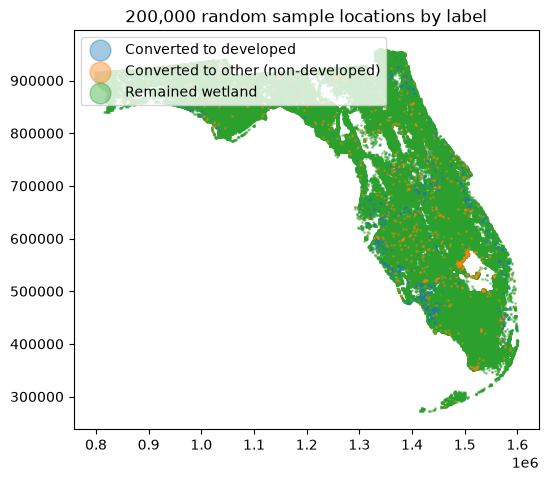

In [6]:
spatial_sample = con.execute("""
    SELECT x, y, label_name
    FROM samples
    USING SAMPLE 200000 ROWS
""").df()

fig, ax = plt.subplots(figsize=(6, 8))
for name, grp in spatial_sample.groupby("label_name"):
    # converted classes plotted last / on top so they aren't buried under the
    # much larger "remained wetland" cloud
    z = 2 if name == "Remained wetland" else 3
    ax.scatter(grp["x"], grp["y"], s=1, alpha=0.4, label=name, zorder=z)
ax.set_aspect("equal")
ax.set_title(f"{len(spatial_sample):,} random sample locations by label")
ax.legend(markerscale=15, loc="upper left")

### `dist_to_developed_2019_m` versus label

Distance to the nearest 2019 developed pixel is one of the strongest priors
for conversion risk: proximity to existing development. Pixels that converted
between 2019 and 2024 should sit closer to 2019 development on average than
pixels that stayed wetland. If they don't, that's worth understanding before
we treat this column as a trustworthy feature.

In [7]:
dist_by_label = con.execute("""
    SELECT label_name,
           COUNT(*) AS n,
           AVG(dist_to_developed_2019_m) AS mean_dist_m,
           MEDIAN(dist_to_developed_2019_m) AS median_dist_m
    FROM samples
    GROUP BY label_name
    ORDER BY mean_dist_m
""").df()
dist_by_label

,label_name,n,mean_dist_m,median_dist_m
0,Converted to developed,165908,88.230664,42.426407
1,Converted to other (non-developed),223253,1101.231279,424.264069
2,Remained wetland,58878170,1605.006973,510.000000


## Data Training

Turn the validated samples into something a model can actually train on.
Three problems need solving before any `.fit()` call is possible: the full
table doesn't fit in memory (59M rows, about 46GB dense versus 17GB here),
the classes are severely imbalanced (0.28% conversions), and neighboring
pixels are spatially correlated so a naive random split would leak. This
section builds the feature and target columns, a spatial fold split grouped
by `block_id`, and a weighted training sample that oversamples conversions
and wetland sitting close to existing development. No model gets fit here,
that's the next section. The deliverable is a persisted weighted training
pool plus an `iter_folds()` generator yielding
`(X_train, y_train, w_train, X_test, y_test)` per fold.

In [8]:
import duckdb
import numpy as np
import pandas as pd

JOINED_GLOB = "data/processed/alphaearth_wetland_joined/*.parquet"
TRAIN_POOL_PATH = "data/processed/gb_train_pool.parquet"

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW samples AS SELECT * FROM read_parquet('{JOINED_GLOB}')")

BAND_COLS = [f"A{b:02d}_{year}" for year in (2017, 2018, 2019) for b in range(64)]
DIST_COL = "dist_to_developed_2019_m"
DIST_NORM_COL = "dist_log_z"
TARGET_COL = "label_bin"
FEATURE_COLS = [DIST_NORM_COL] + BAND_COLS

### Target and features

The question we're actually asking is "does this convert to *developed*,"
not "does this change at all." So `label_bin` collapses `label == 2`
(converted to some other, not developed, class) into the negative class
right alongside `label == 0` (stayed wetland). Features are the 192
embedding bands plus `dist_to_developed_2019_m`, normalized below.

### Assigning blocks to folds

`block_id` (about 10km cells, baked in by `join_alphaearth_samples.py`'s
`add_block_id`) exists so spatially correlated neighboring pixels don't
straddle a train and test boundary. See the comment at
`join_alphaearth_samples.py`, lines 60 to 65. So the split has to happen at
the block level, not the row level, and every row of a given block has to
land in the same fold.

`GroupKFold` over 59M individual row labels isn't necessary. There are only
1,727 distinct blocks, small enough to assign in pandas and join back. The
assignment also can't just be `hash(block_id) % k` or a plain row count
balance: block size is wildly uneven (1 to 111,527 rows) and so is positive
count (0 to 3,708 per block), with 427 of 1,727 blocks (24.7%) having zero
label=1 rows at all. Balancing on row count alone could easily leave one
fold starved for positives. So this greedily hands each block to whichever
fold currently has the fewest positives, working through blocks in
descending order of positive count first (the scarce resource), falling
back to row count as a tiebreaker.

In [9]:
K_FOLDS = 5

block_stats = con.execute("""
    SELECT block_id,
           COUNT(*) AS n,
           SUM(CASE WHEN label = 1 THEN 1 ELSE 0 END) AS n_pos
    FROM samples
    GROUP BY block_id
""").df()

# shuffle first so ties in n_pos (e.g. all the zero positive blocks) don't all
# land in fold 0 just because that's parquet scan order
block_stats = block_stats.sample(frac=1, random_state=0).reset_index(drop=True)
order = block_stats.sort_values("n_pos", ascending=False, kind="mergesort").index

fold_pos = np.zeros(K_FOLDS)
fold_n = np.zeros(K_FOLDS)
fold_of = np.empty(len(block_stats), dtype=int)
for i in order:
    j = np.lexsort((fold_n, fold_pos))[0]  # fold with the fewest positives so far, ties broken by row count
    fold_of[i] = j
    fold_pos[j] += block_stats.at[i, "n_pos"]
    fold_n[j] += block_stats.at[i, "n"]
block_stats["fold"] = fold_of

block_stats.groupby("fold")[["n", "n_pos"]].sum()

,n,n_pos
fold,,
0,8564755,33182.0
1,17006286,33181.0
2,8663148,33182.0
3,16992703,33181.0
4,8040439,33182.0


In [10]:
# block_stats is tiny (1,727 rows), so register it directly as an in memory
# table and join against the full glob instead of writing it to a file first
con.register("block_fold", block_stats[["block_id", "fold"]])
con.execute("""
    CREATE OR REPLACE VIEW samples_fold AS
    SELECT s.*, bf.fold
    FROM samples s
    JOIN block_fold bf USING (block_id)
""")

### Weighted training sample

At 0.28% positive, training on the natural distribution would leave a GBM
with almost nothing to learn the minority class from. The fix is a per row
inclusion probability, not a hard filter. Every row keeps some chance of
being drawn, so the training pool is a biased *sample* of the full
population rather than a restricted subset of it:

- `label == 1` (conversions) and `label == 2` (converted to other): always
  included, `p = 1`. Both are small (166K and 223K rows) against the about
  2.5M row budget, so there's no reason to thin either. `label == 2` rows
  still end up as `label_bin = 0`, they just aren't restricted by sampling.
- `label == 0`: inclusion probability decays smoothly with
  `dist_to_developed_2019_m`: `p0(dist) = P_FLOOR + A * exp(-dist / TAU_M)`,
  clipped to 1. `TAU_M = 200` matches the distance regime real conversions
  happen in (label=1 median 42m, p90 195m), so the boost concentrates on
  wetland sitting in the same band where conversions actually occur: the
  "hard negatives" a classifier most needs to see. `P_FLOOR` keeps distant
  wetland from ever hitting zero probability.

`A` is solved below in closed form from the target pool size instead of
tuning it by trial and error, using `E[exp(-dist/TAU_M)]` over all label=0
rows (one duckdb aggregate).

In [11]:
TAU_M = 200.0
P_FLOOR = 0.01
TARGET_TOTAL = 2_500_000

label_totals = con.execute("SELECT label, COUNT(*) AS n FROM samples GROUP BY label").df().set_index("label")["n"]

mean_decay = con.execute(f"""
    SELECT AVG(EXP(-{DIST_COL} / {TAU_M})) AS m FROM samples WHERE label = 0
""").df()["m"][0]

# solve for A such that E[p0(dist)] over label=0 rows lands the label=0 draw
# right at whatever's left of the budget after label 1/2 are taken in full
remaining_budget = TARGET_TOTAL - label_totals.get(1, 0) - label_totals.get(2, 0)
target_avg_p0 = remaining_budget / label_totals[0]
A = (target_avg_p0 - P_FLOOR) / mean_decay
target_avg_p0, A

(np.float64(0.035850961400464725), np.float64(0.12012770743425566))

In [12]:
# cheap sanity check before spending the real scan: the actual random() draw
# below touches all 192 band columns for every retained row, not worth
# rerunning just to discover the budget was off
con.execute(f"""
    SELECT SUM(CASE WHEN label IN (1, 2) THEN 1.0
                     ELSE LEAST(1.0, {P_FLOOR} + {A} * EXP(-{DIST_COL} / {TAU_M})) END) AS expected_n
    FROM samples
""").df()

,expected_n
0,2.500000e+06


### Draw and persist the pool

One pass over the full glob, `WHERE random() < p_include`. This single draw
covers every fold at once: inclusion only depends on `label` and `dist`,
never on `fold`, so a given fold's training set is just this pool filtered
to `fold != k` later on.

`sample_weight = 1 / p_include` rides along so the model can correct for the
biased draw during fitting. Without it, predicted probabilities would come
out skewed high in the oversampled region near development, since the model
would see far more positives and hard negatives there than actually occur.

Writes to `data/processed/gb_train_pool.parquet` so this cell (slow, a full
9GB scan) doesn't rerun on every kernel restart. It goes stale if `TAU_M`,
`P_FLOOR`, `TARGET_TOTAL`, or the seed change above. Delete the file and
rerun this cell if any of those get tuned.

In [13]:
import os

if os.path.exists(TRAIN_POOL_PATH):
    train_pool = pd.read_parquet(TRAIN_POOL_PATH)
else:
    con.execute("SELECT setseed(0.42)")  # duckdb's random() isn't fixed across calls otherwise
    train_pool = con.execute(f"""
        WITH scored AS (
            SELECT *,
                   CASE WHEN label IN (1, 2) THEN 1.0
                        ELSE LEAST(1.0, {P_FLOOR} + {A} * EXP(-{DIST_COL} / {TAU_M})) END AS p_include
            FROM samples_fold
        )
        SELECT block_id, fold, {DIST_COL},
               {", ".join(BAND_COLS)},
               CASE WHEN label = 1 THEN 1 ELSE 0 END AS {TARGET_COL},
               p_include
        FROM scored
        WHERE random() < p_include
    """).df()
    train_pool["sample_weight"] = 1.0 / train_pool["p_include"]
    train_pool.to_parquet(TRAIN_POOL_PATH, index=False)

len(train_pool), train_pool[TARGET_COL].mean()

(2502076, np.float64(0.0663081377224353))

### Per fold distance normalization

The one place leakage could sneak back in: the log1p and z score stats for
`dist_to_developed_2019_m` have to be fit only on that fold's training rows.
Fit them off `samples_fold WHERE fold != k`, the raw natural distribution,
not `train_pool`. The pool's distance profile is deliberately skewed by the
weighting above, and doesn't represent the population the model needs to
generalize to at test time.

In [14]:
def fit_dist_normalizer(fold_id: int) -> tuple[float, float]:
    stats = con.execute(f"""
        SELECT AVG(LN(1 + {DIST_COL})) AS log_mean,
               STDDEV(LN(1 + {DIST_COL})) AS log_std
        FROM samples_fold
        WHERE fold != {fold_id}
    """).df()
    return stats["log_mean"][0], stats["log_std"][0]


def add_normalized_dist(df: pd.DataFrame, log_mean: float, log_std: float) -> pd.DataFrame:
    df = df.copy()
    df[DIST_NORM_COL] = (np.log1p(df[DIST_COL]) - log_mean) / log_std
    return df

### Held out fold, natural distribution

Test rows are pulled unweighted. The point of evaluation is an honest read
on the real 0.28% imbalance, not the boosted training distribution. This
pulls the full natural fold (about 11.8M rows per fold, about 9GB as
float32 across 192 band columns), with no sampling cap. That's a real
memory risk stacked on top of the about 2GB weighted `train_pool`. On a
17GB machine, process one fold at a time and let its frames go out of scope
before moving to the next, rather than holding all 5 folds' test sets at
once. `iter_folds` below does this by construction, since it's a generator.

In [15]:
def fold_test_frame(fold_id: int) -> pd.DataFrame:
    return con.execute(f"""
        SELECT {DIST_COL}, {", ".join(BAND_COLS)},
               CASE WHEN label = 1 THEN 1 ELSE 0 END AS {TARGET_COL}
        FROM samples_fold
        WHERE fold = {fold_id}
    """).df()

### Worked example: fold 0

Wire it together for one fold before generalizing. The sanity check at the
end matters: train's positive rate should sit far above the natural about
0.28% (oversampling doing its job), and test's should land close to it
(natural distribution, an honest evaluation).

In [16]:
FOLD_ID = 0
log_mean, log_std = fit_dist_normalizer(FOLD_ID)

train_fold = train_pool[train_pool["fold"] != FOLD_ID].pipe(add_normalized_dist, log_mean, log_std)
test_fold = fold_test_frame(FOLD_ID).pipe(add_normalized_dist, log_mean, log_std)

X_train, y_train, w_train = train_fold[FEATURE_COLS], train_fold[TARGET_COL], train_fold["sample_weight"]
X_test, y_test = test_fold[FEATURE_COLS], test_fold[TARGET_COL]

len(train_fold), train_fold[TARGET_COL].mean(), len(test_fold), test_fold[TARGET_COL].mean()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(2082323,
 np.float64(0.06373939105508608),
 8564755,
 np.float64(0.0038742497596253485))

### All folds

A generator rather than a materialized list of all k folds' data. There's no
reason to pay for holding all 5 folds' train and test frames at once, when
the Model Training section is just going to loop through them one at a time
anyway.

In [17]:
def iter_folds(k: int = K_FOLDS):
    for fold_id in range(k):
        log_mean, log_std = fit_dist_normalizer(fold_id)
        train_fold = train_pool[train_pool["fold"] != fold_id].pipe(add_normalized_dist, log_mean, log_std)
        test_fold = fold_test_frame(fold_id).pipe(add_normalized_dist, log_mean, log_std)
        yield (
            fold_id,
            train_fold[FEATURE_COLS], train_fold[TARGET_COL], train_fold["sample_weight"],
            test_fold[FEATURE_COLS], test_fold[TARGET_COL],
        )

## Model Training

Fit one LightGBM classifier per fold, default hyperparameters throughout.
`random_state=0` is set only for reproducibility, not tuning. Each fold's model
trains on that fold's weighted `train_pool` split and gets scored against its
own natural, unweighted test partition, so the reported metrics reflect the
real about 0.28% base rate, not the oversampled one. Nothing here picks a best
model. This is a first read on whether the embeddings and distance feature
carry signal at all, before any tuning happens.

In [18]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    auc,
    roc_auc_score,
    roc_curve,
    accuracy_score,
)

### Choosing an operating point

`precision_recall_curve` returns one more precision and recall pair than it
does thresholds. The last pair, precision 1 and recall 0, is the curve's
closed endpoint and has no threshold behind it, so it gets dropped before
pairing precision and recall up with thresholds for the F1 search below.

The threshold this picks is chosen by looking at the same fold it gets applied
to, so the precision, recall, and F1 reported at it are a best case read, not
what a threshold picked ahead of time without seeing this data would give
you.

In [19]:
def best_f1_operating_point(precision, recall, thresholds):
    precision, recall = precision[:-1], recall[:-1]
    f1 = np.divide(
        2 * precision * recall, precision + recall,
        out=np.zeros_like(precision), where=(precision + recall) > 0,
    )
    best_idx = np.argmax(f1)
    return thresholds[best_idx], precision[best_idx], recall[best_idx], f1[best_idx]

### All folds

A loop instead of a function, since nothing later needs to rerun this per
fold the way `iter_folds` needed to be reusable. Curve arrays and scalar
metrics get kept for plotting and the summary table. The fold's own
`X_test`, `y_test`, and predicted probabilities do not: they get dropped
before the loop asks `iter_folds` for the next fold.

That ordering matters more than it looks. `iter_folds` builds the next
fold's test frame while the previous fold's variables are still bound to
the old names, so anything not explicitly cleared here sits in memory
alongside the next fold's frame while it's being built, right when fold 1
or 2 (about 13GB as float32) is the one coming up.

In [21]:
models = []
fold_metrics = []
roc_curves = {}
pr_curves = {}

for fold_id, X_train, y_train, w_train, X_test, y_test in iter_folds():
    model = lgb.LGBMClassifier(random_state=0)
    model.fit(X_train, y_train, sample_weight=w_train)
    models.append(model)

    proba = model.predict_proba(X_test)[:, 1]
    prevalence = float(y_test.mean())

    avg_prec = average_precision_score(y_test, proba)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)

    best_threshold, best_p, best_r, best_f1 = best_f1_operating_point(precision, recall, pr_thresholds)
    accuracy = accuracy_score(y_test, proba >= best_threshold)

    fold_metrics.append({
        "fold": fold_id, "avg_precision": avg_prec, "pr_auc": pr_auc,
        "accuracy": accuracy, "roc_auc": roc_auc,
        "precision": best_p, "recall": best_r, "f1": best_f1,
        "best_threshold": best_threshold, "prevalence": prevalence,
    })
    roc_curves[fold_id] = (fpr, tpr)
    pr_curves[fold_id] = (recall, precision)

    print(f"fold {fold_id}: AP={avg_prec:.3f}  PR-AUC={pr_auc:.3f}  ROC-AUC={roc_auc:.3f}")
    del X_train, y_train, w_train, X_test, y_test, proba

pd.DataFrame(fold_metrics)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Number of positive: 132726, number of negative: 1949597


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076734 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14108
[LightGBM] [Info] Number of data points in the train set: 2082323, number of used features: 193
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002620 -> initscore=-5.942074
[LightGBM] [Info] Start training from score -5.942074


fold 0: AP=0.064  PR-AUC=0.064  ROC-AUC=0.935


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[LightGBM] [Info] Number of positive: 132726, number of negative: 1958801


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14093
[LightGBM] [Info] Number of data points in the train set: 2091527, number of used features: 193
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002580 -> initscore=-5.957474
[LightGBM] [Info] Start training from score -5.957474


fold 4: AP=0.090  PR-AUC=0.091  ROC-AUC=0.953


,fold,avg_precision,pr_auc,accuracy,roc_auc,precision,recall,f1,best_threshold,prevalence
0,0,0.064105,0.064384,0.987500,0.934900,0.096016,0.264571,0.140898,0.067576,0.003874
1,1,0.058637,0.058678,0.993716,0.965832,0.090547,0.245562,0.132308,0.067578,0.001951
2,2,0.062473,0.063103,0.987676,0.940495,0.088489,0.238412,0.129072,0.077013,0.003830
3,3,0.061993,0.062704,0.993551,0.964503,0.094951,0.269914,0.140483,0.066182,0.001953
4,4,0.089940,0.090688,0.988576,0.952983,0.125555,0.296426,0.176396,0.067697,0.004127


### Summary across folds

One row per fold, columns in the order that matters most first: average
precision and PR-AUC, since those are what actually matter at this base
rate, then accuracy and ROC-AUC, then the operating point chosen from the
F1 search above.

`average_precision_score` and `pr_auc` are two different computations off
the same curve: a step summed area versus a trapezoid integrated one. They
track closely but aren't the same number and shouldn't be read as
redundant. `best_threshold` isn't comparable across folds the way the
other columns are, since each fold trains its own model with its own
probability scale. It's carried along for reference, not as a value meant
to generalize past its own fold.

In [22]:
SUMMARY_COLS = ["avg_precision", "pr_auc", "accuracy", "roc_auc", "precision", "recall", "f1", "best_threshold"]

fold_summary = pd.DataFrame(fold_metrics).set_index("fold")[SUMMARY_COLS]
fold_summary = pd.concat([fold_summary, fold_summary.agg(["mean", "std"])])
fold_summary

,avg_precision,pr_auc,accuracy,roc_auc,precision,recall,f1,best_threshold
0,0.064105,0.064384,0.987500,0.934900,0.096016,0.264571,0.140898,0.067576
1,0.058637,0.058678,0.993716,0.965832,0.090547,0.245562,0.132308,0.067578
2,0.062473,0.063103,0.987676,0.940495,0.088489,0.238412,0.129072,0.077013
3,0.061993,0.062704,0.993551,0.964503,0.094951,0.269914,0.140483,0.066182
4,0.089940,0.090688,0.988576,0.952983,0.125555,0.296426,0.176396,0.067697
mean,0.067430,0.067911,0.990204,0.951742,0.099112,0.262977,0.143831,0.069209
std,0.012740,0.012911,0.003158,0.013902,0.015103,0.022783,0.018914,0.004407


### ROC by fold

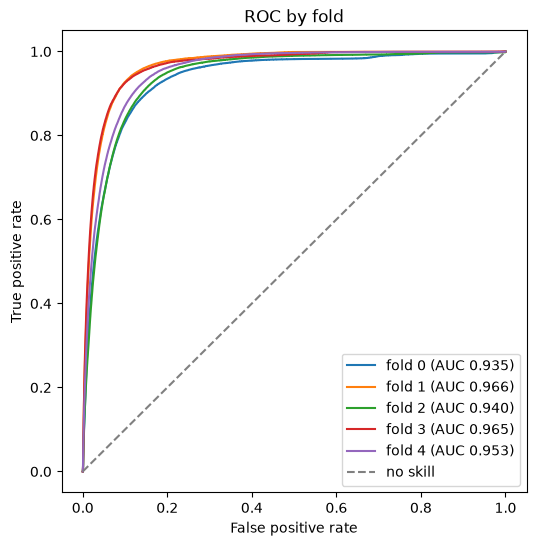

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
for fold_id, (fpr, tpr) in roc_curves.items():
    ax.plot(fpr, tpr, label=f"fold {fold_id} (AUC {fold_summary.loc[fold_id, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="no skill")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC by fold")
ax.legend(loc="lower right")

### Precision and recall by fold

Worth remembering when reading this one: prevalence sets the no skill
baseline for a precision recall curve, and it isn't the same across folds
(about 0.19% to 0.43%, since fold assignment balanced on positive count
rather than row count, so the denominator moves fold to fold). A curve that
looks weak in isolation may still be doing real work relative to that
fold's own chance level.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
for fold_id, (recall, precision) in pr_curves.items():
    ax.plot(recall, precision, label=f"fold {fold_id} (AP {fold_summary.loc[fold_id, 'avg_precision']:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision and recall by fold")
ax.legend(loc="upper right")